# Módulo 3 — Visualización de datos

> Curso de Python para Análisis de Datos en Salud Pública — OPS/PAHO
> Material 2021, actualizado 2026.
> Licencia: código MIT, contenido CC-BY-SA 4.0.


# Módulo 5: Visualización datos con Python

## Obteniendo los datos de servicios de Ecuador

In [ ]:
# Setup módulo de visualización
from pathlib import Path
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/gdrive')
    DATA_DIR = Path('/content/gdrive/MyDrive/Curso_pandas')
except ImportError:
    DATA_DIR = Path.cwd().parent / 'data' if Path.cwd().name == 'notebooks' else Path.cwd() / 'data'


In [ ]:
os.chdir(DATA_DIR)
os.getcwd()


In [ ]:
df = pd.read_csv(f'{DATA_DIR}/2. Datos_abiertos_EEH_2021/egresos_hospitalarios_2021.csv',  sep = ";")

## Configurando los datos de servicios de Ecuador

In [ ]:
# Observaremos los datos
df.head()

In [ ]:
# Vamos a ver la información del dataframe
df.info()

### Cambiando el formato de datos

In [ ]:
# Podemos hacer un cambio automático de los tipos
# Vemos que cambiaron las variables a string 
# Pero el tipo object es más ligero
df.convert_dtypes(infer_objects=True).info()

In [ ]:
# Cambiamos el dataframe
# Sirve solo para el dataframe con los datos leídos del Drive
df[['prov_ubi', 
    'cant_ubi', 
    'parr_ubi', 
    'area_ubi', 
    'clase', 
    'tipo',
    'entidad', 
    'sector', 
    'mes_inv', 
    'nac_pac', 
    'nom_pais',
    'sexo', 
    'cod_edad',
    'etnia', 
    'prov_res', 
    'cant_res', 
    'parr_res',
    'area_res', 
    'mes_ingr', 
    'mes_egr',
    'con_egrpa',
    'esp_egrpa', 
    'cap221rx']]     =   df[['prov_ubi', 
    'cant_ubi', 
    'parr_ubi', 
    'area_ubi', 
    'clase', 
    'tipo',
    'entidad', 
    'sector', 
    'mes_inv', 
    'nac_pac', 
    'nom_pais',
    'sexo', 
    'cod_edad', 
    'etnia', 
    'prov_res', 
    'cant_res', 
    'parr_res',
    'area_res', 
    'mes_ingr', 
    'mes_egr',
    'con_egrpa',
    'esp_egrpa', 
    'cap221rx']].astype('category')
df.dtypes

In [ ]:
#Cambiamos las fechas
# Sirve solo para el dataframe con los datos leídos del Drive

df['fecha_ingr']=pd.to_datetime(
    df['fecha_ingr'],
    errors = 'coerce')

df['fecha_egr']=pd.to_datetime(
    df['fecha_egr'],
    errors = 'coerce')


In [ ]:
# La memoria se optimizó y bajó más de 100 mb
df.info()

## Visualización de datos con Seaborn y Plotly

### Gráficos

Más información en:

[Basic interactive charts with Plotly](https://plotly.com/python/basic-charts/)

[Visualizing distributions of data with Seaborn](https://seaborn.pydata.org/tutorial/distributions.html)

[Visualizing categorical data](https://seaborn.pydata.org/tutorial/categorical.html)






#### Histograma con Pyplot y Seaborn

Más información en:

[Visualizing distributions of data](https://seaborn.pydata.org/tutorial/distributions.html)

[Matplotlib.pyplot.hist](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html)


[Seaborn.histplot](https://seaborn.pydata.org/generated/seaborn.histplot.html)




**Ejemplo**


---

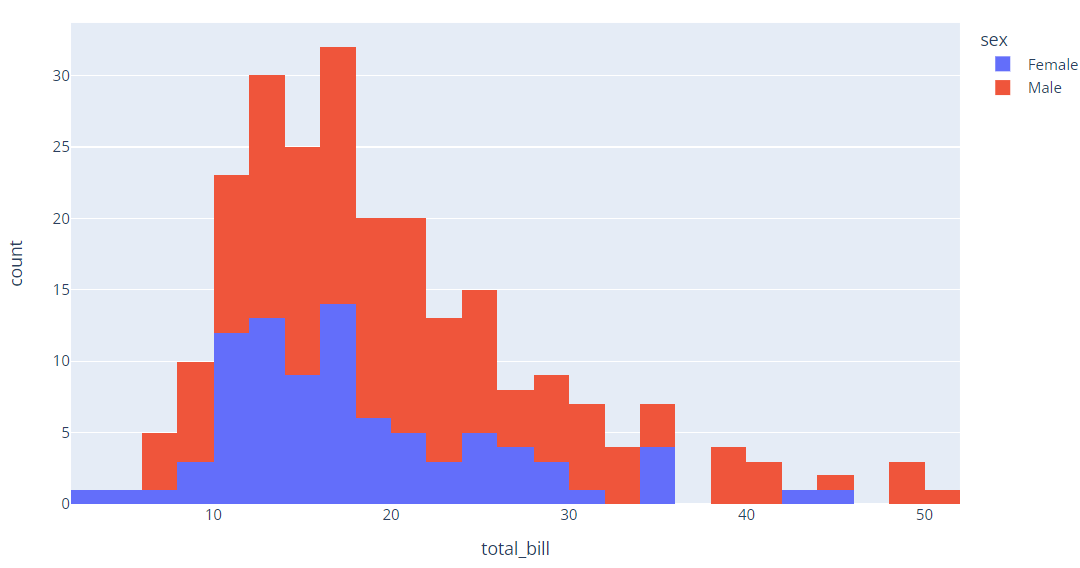


In [ ]:
# Gráfico con Pyplot
# Queremos un histograma con la edad de las personas atendidas

print('La edad promedio es ',df['edad'].mean())
df['edad'].plot.hist()
plt.show() # Usamos plt.show() para no desplegar el nombre del gráfico

In [ ]:
# Haremos el mismo gráfico con Seaborn
# En Seaborn indicamos el conjunto de datos y la variable dentro de la función
sns.histplot(data=df,x='edad')
plt.show()

In [ ]:
# Cambiaremos la cantidad de barras
sns.histplot(data=df,x='edad', bins=10)
plt.show()

Podemos cambiar los colores del gráfico nombrándolo. También se pueden asignar paletas de colores.

Más información en:

[List of named colors](https://matplotlib.org/stable/gallery/color/named_colors.html)

[Choosing color palettes](https://seaborn.pydata.org/tutorial/color_palettes.html)

In [ ]:
# Podemos cambiar los colores
sns.histplot(data=df,x='edad', bins=10, color='lightseagreen')
plt.show()

In [ ]:
# Podemos renombrar los ejes y observar más variables
# Con Hue podemos segmentar los datos y ver cómo se comportan
sns.histplot(data=df,x='edad', bins=10, color='lightseagreen', hue='sexo')
plt.xlabel('Edad de la población atendida')
plt.ylabel('Cantidad')
plt.show()

In [ ]:
# Podemos cambiar el tipo de gráfico al eje Y y hacer barras apiladas
# Cambiamos la variable a y y añadimos la opción stack
sns.histplot(data=df,y='edad', bins=10, color='lightseagreen', hue='sexo', multiple='stack')
plt.ylabel('Edad de la población atendida')
plt.xlabel('Cantidad')
plt.show()

In [ ]:
# Podemos ver los datos en paralelo
sns.histplot(data=df,x='edad', bins=10, color='lightseagreen', hue='sexo', multiple="dodge")
plt.xlabel('Edad de la población atendida')
plt.ylabel('Cantidad')
plt.show()

Podemos notar que entre los 20 y 50 años hay más mujeres que reciben y demandan atención en salud. Probablemente por la maternidad.

#### Histograma interactivo con Plotly

Más información:

[Histograms in Python with Plotly](https://plotly.com/python/histograms/)



**Ejemplo**


---

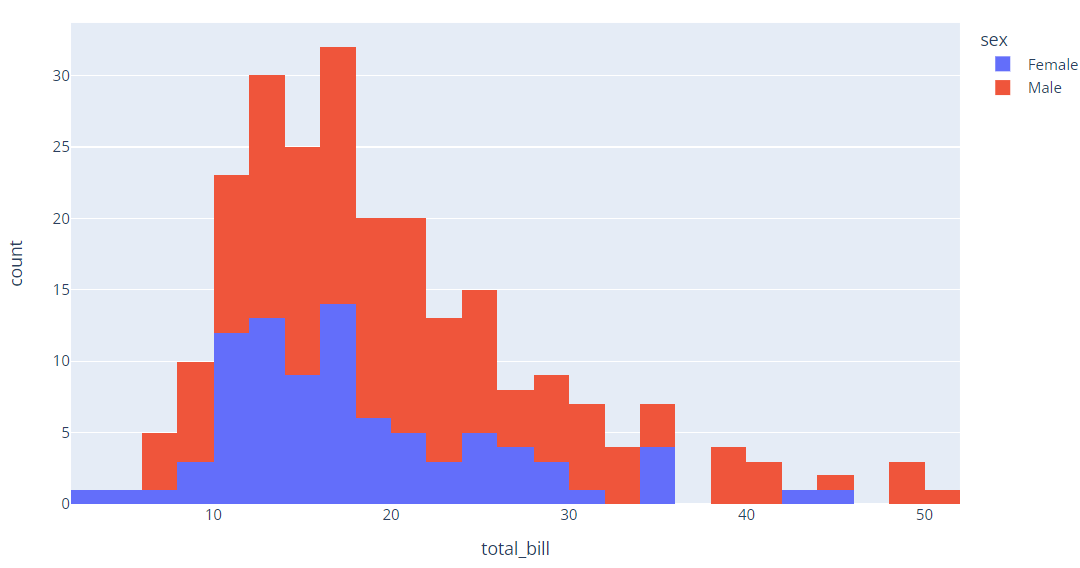

In [ ]:
# Haremos un histograma interactivo

fig = px.histogram(df, x='edad')
fig.show()

In [ ]:
# Es preferible agrupar los datos y tener menos barras
# Aquí usamos nbins en vez de bins para indicar el número de barras
# También vamos a configurar el histograma con update_layout
fig = px.histogram(df, x='edad', nbins=20)
fig.update_layout(title='Distribución de la población atendida por edad',
                  xaxis_title='Edad',
                  yaxis_title='Frecuencia')

fig.show()

In [ ]:
# También lo podemos hacer con barras horizontales
fig = px.histogram(df, y='edad', nbins=20)
fig.update_layout(title='Distribución de la población atendida por edad',
                  xaxis_title='Edad',
                  yaxis_title='Frecuencia')

fig.show()

In [ ]:
# Podemos visualizar las diferencias por sexo
fig = px.histogram(df, x='edad', nbins=50, color='sexo')
fig.update_layout(title='Distribución de la población atendida por edad',
                  xaxis_title='Edad',
                  yaxis_title='Frecuencia')

fig.show()

Para más información sobre el formato puede revisar: 

[Setting the Font, Title, Legend Entries, and Axis Titles in Python](https://plotly.com/python/figure-labels/)

#### Gráfico de torta o pie chart interactivo

Más información:


[Pie Charts in Python with Plotly](https://plotly.com/python/pie-charts/)



**Ejemplo**


---

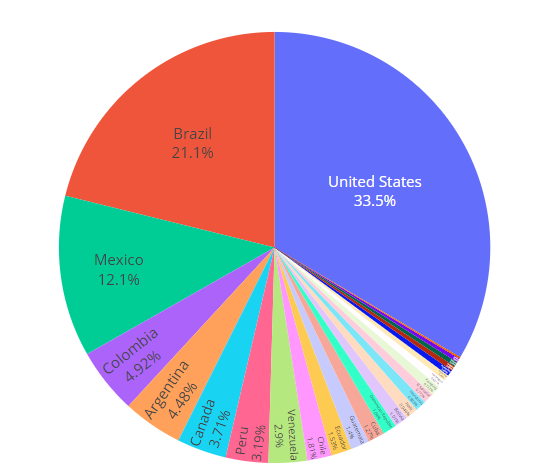

In [ ]:
fig = px.pie(df, names='sector', title='Población atendida según sector del centro de atención')
fig.show()

In [ ]:
# Podemos cambiar la paleta de colores
fig = px.pie(df, names='sector', title='Población atendida según sector del centro de atención',color_discrete_sequence=px.colors.qualitative.Pastel1)
fig.show()

Existen paletas de colores discretas que se usan para datos cualitativos, y otras continuas que van en degradé de colores.

Para las primeras usamos: 
px.colors.qualitative.*nombre_de_la_paleta*

https://plotly.com/python/discrete-color/

Para la segunda usamos:
px.colors.sequential.*nombre_de_la_paleta*

https://plotly.com/python/builtin-colorscales/

In [ ]:
# También podemos escoger que se presenten los nombres de las categorías

fig = px.pie(df, names='sector', 
             title='Población atendida según sector del centro de atención',
             color_discrete_sequence=px.colors.qualitative.G10)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

In [ ]:
# Podemos exportar el gráfico en html para colocarlo en nuestra web
fig.write_html("pie.html")

Puede encontrar más tutoriales en:

[Pie Charts in Python with Plotly](https://plotly.com/python/pie-charts/)

#### Gráfico de barras estático e interactivo

Más información en:

[Grouped barplots](https://seaborn.pydata.org/examples/grouped_barplot.html)

[Visualizing categorical data](https://seaborn.pydata.org/tutorial/categorical.html)


[Interactive Bar Charts](https://plotly.com/python/bar-charts/)




**Ejemplo**


---

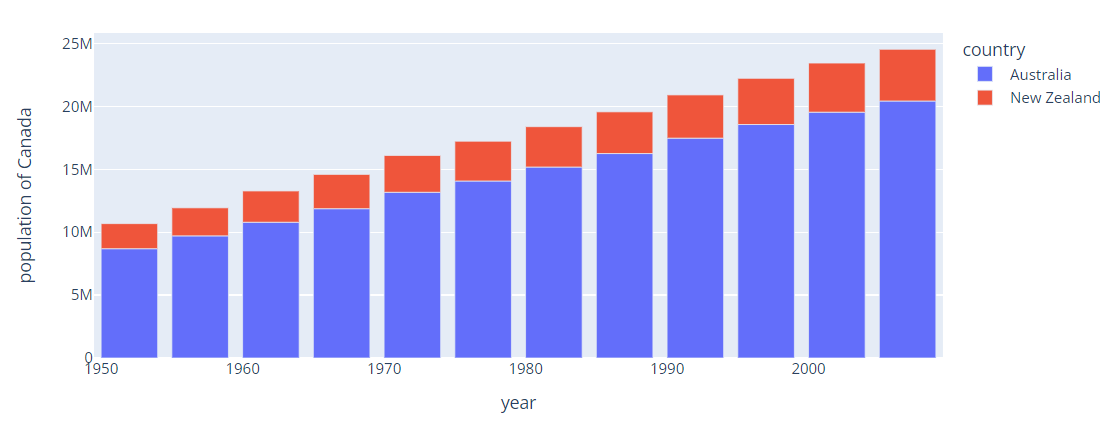

In [ ]:
# Para hacer un gráfico de barras es preferible generar una tabla
# con el resumen de los datos

data = df.groupby(['cap221rx'])[['edad']].aggregate(['mean','count','std','min','max'])
data

In [ ]:
data.index

In [ ]:
sns.catplot(
    data=data, kind="bar",
    x=data.index, y="edad")

Se creó un error al utilizar el index directamente porque este puede ser ambiguo. Por ello vamos a crear una nueva variable con ese dato

In [ ]:
# Creamos una nueva variable para el índice
data['cie-10'] = data.index
data

In [ ]:
# Vamos a observar el nombre de las columnas/variables
data.columns

In [ ]:
# Cambiamos el nombre de las columnas/variables
data.columns=['mean','count','std','min','max','cie-10']

In [ ]:
# Vamos a visualizar los datos
# En el eje x va la edad promedio
# En el eje y el diagnóstico según la CIE-10

sns.catplot(
    data=data, kind='bar',
    x='mean', y='cie-10')
plt.title('Edad promedio por diagnóstico')
plt.ylabel('Edad promedio')
plt.xlabel('Diagnóstico')

plt.show()

Gráfico interactivo

In [ ]:
# Vamos a hacer el mismo gráfico pero interactivo
fig = px.bar(data, x='mean', y='cie-10', title='Edad promedio por diagnóstico',color_discrete_sequence=px.colors.qualitative.G10)
fig.show()

In [ ]:
# Vemos que los datos no están ordenados. 
# Podemos ordenar la tabla para tenerlos de mayor a menor
data = data.sort_values(by='mean', ascending=True)
data

In [ ]:
# Ordenamos de forma distinta el gráfico
# Añadimos las etiquetas con text_auto=True
fig = px.bar(data, x='mean', y='cie-10', 
             title='Edad promedio por diagnóstico',
             color_discrete_sequence=px.colors.qualitative.G10,
             text_auto=True, color='mean')
fig.show()

In [ ]:
# Podemos exportar el gráfico

fig = px.bar(data, x='mean', y='cie-10', 
             title='Edad promedio por diagnóstico',
             color_discrete_sequence=px.colors.qualitative.G10,
             text_auto=True, color='mean',
             width=1400, height=1000)
fig.update_layout(xaxis_title='Edad',
                  yaxis_title='Diagnóstico',
)
fig.show()

#### Gráfico de líneas

Más información en:

[Line Charts in Python with Plotly](https://plotly.com/python/line-charts/)




**Ejemplo**


---

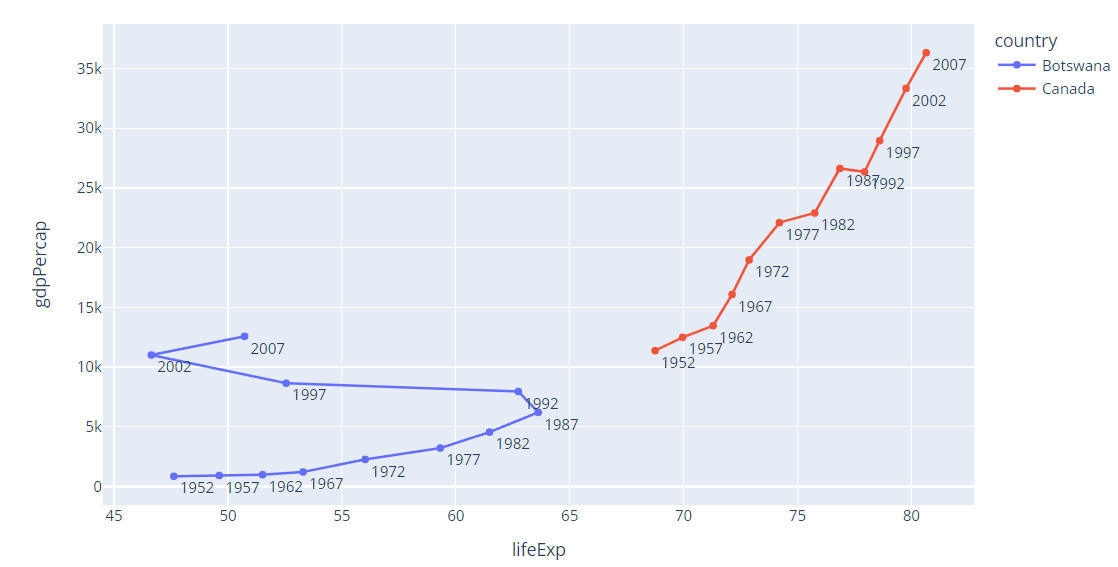

In [ ]:
# Para los gráficos de línea también es mejor crear una tabla con los datos depurados
# Primero creamos una variable para contar la cantidad de pacientes
df['uno'] = 1
data = df.groupby([pd.Grouper(key='fecha_ingr',freq='M')]).sum()
data

In [ ]:
# Vemos que hay datos con errores en la fecha de ingreso
# Filtraremos para obtener solo aquellos posteriores a 2021
data = data[data.index>'2020-12-31']
data

In [ ]:
# Todos los datos se sumaron
# Por eso debemos crear la edad promedio del mes y el promedio de estadía
data['edad_prom'] = data['edad']/data['uno']
data['estad_prom'] = data['dia_estad'] / data['uno']
data['mes'] = data.index.month


In [ ]:
data

In [ ]:
fig = px.line(data, x=data.index, y="uno", title='Pacientes por mes')
fig.show()

Haremos un gráfico con datos para hombres y mujeres

In [ ]:
# Haremos un gráfico de hombres y mujeres
data_sexo=data = df.groupby([pd.Grouper(key='fecha_ingr',freq='M'),'sexo']).sum()
data_sexo = data_sexo[data_sexo.index.get_level_values(0)>'2020-12-31']
data_sexo['edad_prom'] = data_sexo['edad']/data['uno']
data_sexo['estad_prom'] = data_sexo['dia_estad'] / data['uno']
data_sexo['mes'] = data_sexo.index.get_level_values(0).month
data_sexo['sexo'] = data_sexo.index.get_level_values(1)

data_sexo

In [ ]:
# Podemos hacer un gráfico para hombres y mujeres con la etiqueta de los datos
fig = px.line(data_sexo, x="mes", y="uno", color='sexo', text='uno')

# Agregamos botones en los vértices
fig.update_traces(textposition="bottom right")
fig.show()

In [ ]:
# Observamos la edad promedio de los pacientes por mes
# Podemos agregar marcadores
# En las etiquetas colocamos la edad promedio redondeada a dos decimales
fig = px.line(data_sexo, x="mes", y="edad_prom", color='sexo', markers=True, text=data_sexo['edad_prom'].round(2))
fig.show()

#### Gráfico de dispersión
Podemos hacer diagramas de dispersión para observar la relación entre las variables.

Más información en:

[Scatter Plots in Python with Plotly](https://plotly.com/python/line-and-scatter/)




**Ejemplo**


---


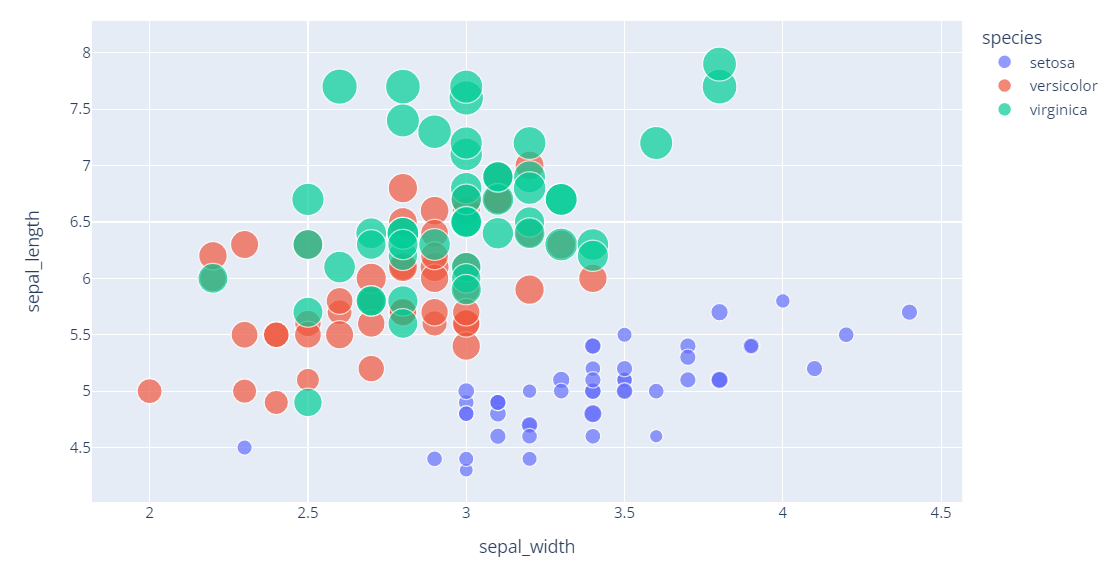

In [ ]:
# Podemos observar la relación entre la edad promedio de los pacientes
# y el número de días de estadía promedio
# Aparentemente a mayor edad aumentan los días de estadía promedio
# Se observa una clara diferencia entre hombres y mujeres
fig = px.scatter(data_sexo, x="edad_prom", y="estad_prom", color='sexo')
fig.show()

In [ ]:
# Podemos añadir un tamaño a los círculos
fig = px.scatter(data_sexo, x="edad_prom", y="estad_prom", color='sexo', size='uno')
fig.show()

In [ ]:
# Vamos a ver los datos coloreados por mes
# Aparentemente al inicio del año llegan los pacientes mayores y con más días de estancia promedio
fig = px.scatter(data_sexo, x="edad_prom", y="estad_prom", color='mes', size='uno')
fig.show()

In [ ]:
# Podemos añadir símbolos para identifiar a hombres de mujeres
fig = px.scatter(data_sexo, x="edad_prom", y="estad_prom", color='mes', size='uno', symbol='sexo')
fig.show()

In [ ]:
# Podemos hacer una matriz con distintas variables
# Podemos ver los datos por columnas
fig = px.scatter(data_sexo, x="edad_prom", y="estad_prom", color="mes", facet_col="sexo")
fig.show()

In [ ]:
# O por filas
fig = px.scatter(data_sexo, x="edad_prom", y="estad_prom", color="mes", facet_row="sexo")
fig.show()

In [ ]:
# Incluso podríamos mezclar filas y columnas

In [ ]:
# No se observa una relación clara entre la edad y los días de estadía en el hospital
fig = px.scatter(data, x='mes',y='estad_prom')
fig.show()

#### Gráficos de densidad  con Seaborn

Más información en:

[Visualizing distributions of data](https://seaborn.pydata.org/tutorial/distributions.html)


**Ejemplo**


---



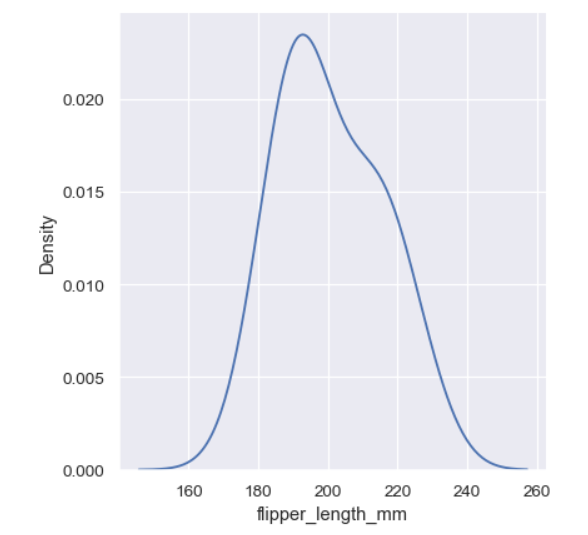




In [ ]:
# Podemos ver la densidad de las edades entre hombres y mujeres

sns.displot(df, x="edad", hue="sexo", kind="kde")
plt.show()

In [ ]:
# Podemos ver las áreas
sns.displot(df, x="edad", hue="sexo", kind="kde", fill=True)
plt.show()